In [ ]:
!pip install -q pyspark

Map Reduce Style Implementation using Github Repo

In [ ]:
!git clone https://github.com/unaizahhhhh/MIT805-Group-4-Assignment.git

Cloning into 'MIT805-Group-4-Assignment'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 189 (delta 15), reused 23 (delta 10), pack-reused 161 (from 2)
Receiving objects: 100% (189/189), 1.55 GiB | 18.09 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Updating files: 100% (138/138), done.


In [ ]:
!cd MIT805-Group-4-Assignment && git pull

Already up to date.


In [ ]:
!ls MIT805-Group-4-Assignment/data/

flight_with_weather_2016  flight_with_weather_2020  flight_with_weather_2024
flight_with_weather_2017  flight_with_weather_2021  README.md
flight_with_weather_2018  flight_with_weather_2022
flight_with_weather_2019  flight_with_weather_2023


In [ ]:
!ls MIT805-Group-4-Assignment/
!ls MIT805-Group-4-Assignment/src/

data  figures  notebooks  README.md  report  requirements.txt  src
aggregate.py  __init__.py  README.md  transform.py


In [ ]:
!du -sh MIT805-Group-4-Assignment/data/

2.4G	MIT805-Group-4-Assignment/data/


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FlightDelayMapReduce") \
    .getOrCreate()

spark

In [ ]:
YEARS = range(2016, 2025)
paths = [f"MIT805-Group-4-Assignment/data/flight_with_weather_{y}/" for y in YEARS]

df_all = spark.read.parquet(*paths)

df_all.printSchema()
print(f"Partitions: {df_all.rdd.getNumPartitions()}")

root
 |-- FL_DATE: timestamp (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: double (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: timestamp (nullable = true)
 |-- DEP_TIME: timestamp (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: timestamp (nullable = true)
 |-- WHEELS_ON: timestamp (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: timestamp (nullable = true)
 |-- ARR_TIME: timestamp (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ACTUAL_ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)
 |-- FLIGHTS: double (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- ORIGIN_INDEX: integer (nullable = true)
 |-- DES

In [ ]:
df_all.printSchema()
print(f"Rows: {df_all.count():,}")
print(f"Columns: {len(df_all.columns)}")
print(df_all.columns)

root
 |-- FL_DATE: timestamp (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- OP_CARRIER_FL_NUM: double (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- CRS_DEP_TIME: timestamp (nullable = true)
 |-- DEP_TIME: timestamp (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- TAXI_OUT: double (nullable = true)
 |-- WHEELS_OFF: timestamp (nullable = true)
 |-- WHEELS_ON: timestamp (nullable = true)
 |-- TAXI_IN: double (nullable = true)
 |-- CRS_ARR_TIME: timestamp (nullable = true)
 |-- ARR_TIME: timestamp (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- CRS_ELAPSED_TIME: double (nullable = true)
 |-- ACTUAL_ELAPSED_TIME: double (nullable = true)
 |-- AIR_TIME: double (nullable = true)
 |-- FLIGHTS: double (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- ORIGIN_INDEX: integer (nullable = true)
 |-- DES

In [ ]:
df_all.show(5, truncate=False)

+-------------------+----------+-----------------+------+----+-------------------+-------------------+---------+--------+-------------------+-------------------+-------+-------------------+-------------------+---------+----------------+-------------------+--------+-------+-----+------------+-----------+------------+----------+------+------+------+------+------+------+----------+-----------+----------+-----------+
|FL_DATE            |OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME       |DEP_TIME           |DEP_DELAY|TAXI_OUT|WHEELS_OFF         |WHEELS_ON          |TAXI_IN|CRS_ARR_TIME       |ARR_TIME           |ARR_DELAY|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|FLIGHTS|MONTH|DAY_OF_MONTH|DAY_OF_WEEK|ORIGIN_INDEX|DEST_INDEX|O_TEMP|O_PRCP|O_WSPD|D_TEMP|D_PRCP|D_WSPD|O_LATITUDE|O_LONGITUDE|D_LATITUDE|D_LONGITUDE|
+-------------------+----------+-----------------+------+----+-------------------+-------------------+---------+--------+-------------------+-------------------+-----

In [ ]:
df_all.describe().show()

+-------+----------+------------------+--------+--------+------------------+-----------------+-----------------+-----------------+------------------+-------------------+------------------+--------+-----------------+------------------+------------------+------------------+-----------------+------------------+-------------------+------------------+-----------------+-------------------+------------------+----------------+------------------+-----------------+------------------+
|summary|OP_CARRIER| OP_CARRIER_FL_NUM|  ORIGIN|    DEST|         DEP_DELAY|         TAXI_OUT|          TAXI_IN|        ARR_DELAY|  CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|          AIR_TIME| FLIGHTS|            MONTH|      DAY_OF_MONTH|       DAY_OF_WEEK|      ORIGIN_INDEX|       DEST_INDEX|            O_TEMP|             O_PRCP|            O_WSPD|           D_TEMP|             D_PRCP|            D_WSPD|      O_LATITUDE|       O_LONGITUDE|       D_LATITUDE|       D_LONGITUDE|
+-------+----------+------------------+---

In [ ]:
from pyspark.sql import functions as F

df_all.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_all.columns
]).show()

+-------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+-------------------+--------+-------+-----+------------+-----------+------------+----------+------+------+------+------+------+------+----------+-----------+----------+-----------+
|FL_DATE|OP_CARRIER|OP_CARRIER_FL_NUM|ORIGIN|DEST|CRS_DEP_TIME|DEP_TIME|DEP_DELAY|TAXI_OUT|WHEELS_OFF|WHEELS_ON|TAXI_IN|CRS_ARR_TIME|ARR_TIME|ARR_DELAY|CRS_ELAPSED_TIME|ACTUAL_ELAPSED_TIME|AIR_TIME|FLIGHTS|MONTH|DAY_OF_MONTH|DAY_OF_WEEK|ORIGIN_INDEX|DEST_INDEX|O_TEMP|O_PRCP|O_WSPD|D_TEMP|D_PRCP|D_WSPD|O_LATITUDE|O_LONGITUDE|D_LATITUDE|D_LONGITUDE|
+-------+----------+-----------------+------+----+------------+--------+---------+--------+----------+---------+-------+------------+--------+---------+----------------+-------------------+--------+-------+-----+------------+-----------+------------+----------+------+------+------+------+------+----

Running the Map stage

In [ ]:
import sys
sys.path.append("MIT805-Group-4-Assignment/src")

from transform import clean_and_derive

df_clean = clean_and_derive(df_all)
df_clean.cache()

df_clean.printSchema()
print(f"Total rows: {df_clean.count():,}")
df_clean.show(5, truncate=False)

root
 |-- FL_DATE: date (nullable = true)
 |-- OP_CARRIER: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- DEST: string (nullable = true)
 |-- DEP_DELAY: double (nullable = true)
 |-- ARR_DELAY: double (nullable = true)
 |-- O_PRCP: double (nullable = true)
 |-- D_PRCP: double (nullable = true)
 |-- O_TEMP: double (nullable = true)
 |-- D_TEMP: double (nullable = true)
 |-- O_WSPD: double (nullable = true)
 |-- D_WSPD: double (nullable = true)
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY_OF_WEEK: string (nullable = true)
 |-- ROUTE: string (nullable = false)
 |-- DELAYED_15: integer (nullable = false)
 |-- SEVERE_DELAY_60: integer (nullable = false)
 |-- PRECIPITATION_CATEGORY: string (nullable = false)

Total rows: 54,674,003
+----------+----------+------+----+---------+---------+------+------+------+------+------+------+----+-----+-----------+-------+----------+---------------+----------------------+
|FL_DATE   |OP_CARRIER|OR

In [ ]:
from aggregate import overall_summary, carrier_delay_summary, weather_delay_comparison, yearly_trend, weather_correlation, day_of_week_summary, origin_airport_summary, carrier_delay_percentiles, delay_by_carrier_rdd

In [ ]:
overall_summary(df_clean).show(truncate=False)

+-------------+---------------+-------------+-------------+----------------+-----------------------+
|total_flights|delayed_flights|severe_delays|average_delay|delay_percentage|severe_delay_percentage|
+-------------+---------------+-------------+-------------+----------------+-----------------------+
|54674003     |10116916       |3360584      |4.48         |18.5            |6.15                   |
+-------------+---------------+-------------+-------------+----------------+-----------------------+



In [ ]:
carrier_delay_summary(df_clean).show(20, truncate=False)

+----------+-------------+---------------+-------------+----------------+
|OP_CARRIER|total_flights|delayed_flights|average_delay|delay_percentage|
+----------+-------------+---------------+-------------+----------------+
|B6        |2236608      |590147         |11.34        |26.39           |
|F9        |1176549      |305928         |11.03        |26.0            |
|VX        |155092       |39008          |8.44         |25.15           |
|G4        |303824       |76198          |12.31        |25.08           |
|NK        |1696082      |371387         |7.54         |21.9            |
|AA        |7518473      |1532817        |7.0          |20.39           |
|EV        |1178841      |231615         |7.4          |19.65           |
|WN        |11133643     |2151883        |3.85         |19.33           |
|YV        |818626       |158168         |7.97         |19.32           |
|UA        |5083571      |948076         |4.35         |18.65           |
|OH        |1538083      |284175      

In [ ]:
route_weather = weather_delay_comparison(df_clean, "ROUTE").filter(
    (F.col("dry_flights") >= 3000) & (F.col("rain_flights") >= 500)
)
route_weather.show(20, truncate=False)

+-------+-----------+--------------------+-----------------+------------+---------------------+------------------+-------------------------+----------------------+
|ROUTE  |dry_flights|dry_delay_percentage|dry_average_delay|rain_flights|rain_delay_percentage|rain_average_delay|delay_percentage_increase|average_delay_increase|
+-------+-----------+--------------------+-----------------+------------+---------------------+------------------+-------------------------+----------------------+
|PSP-SFO|20181      |21.14               |7.34             |1471        |49.42                |40.29             |28.28                    |32.95                 |
|HDN-DEN|6843       |19.16               |1.94             |877         |47.43                |31.8              |28.27                    |29.86                 |
|DEN-COS|24968      |21.88               |9.25             |1630        |48.53                |36.58             |26.65                    |27.33                 |
|LAS-SFO|53515  

In [ ]:
carrier_weather = weather_delay_comparison(df_clean, "OP_CARRIER")
carrier_weather.show(20, truncate=False)

+----------+-----------+--------------------+-----------------+------------+---------------------+------------------+-------------------------+----------------------+
|OP_CARRIER|dry_flights|dry_delay_percentage|dry_average_delay|rain_flights|rain_delay_percentage|rain_average_delay|delay_percentage_increase|average_delay_increase|
+----------+-----------+--------------------+-----------------+------------+---------------------+------------------+-------------------------+----------------------+
|EV        |1015918    |17.55               |4.98             |156781      |33.33                |23.04             |15.78                    |18.06                 |
|MQ        |1518919    |16.31               |2.08             |228173      |32.0                 |17.1              |15.69                    |15.02                 |
|VX        |137370     |23.37               |6.51             |17717       |39.0                 |23.4              |15.63                    |16.89                 

In [ ]:
yearly_trend(df_clean).show(9)

+----+-------------+-------------+----------------+
|YEAR|total_flights|average_delay|delay_percentage|
+----+-------------+-------------+----------------+
|2016|      5537987|         3.52|           17.41|
|2017|      5575872|         4.32|           18.45|
|2018|      6986842|          5.0|           19.09|
|2019|      7161827|         5.38|           19.11|
|2020|      4312091|        -5.11|            9.73|
|2021|      5755666|         2.95|           17.08|
|2022|      6413416|         6.93|           20.99|
|2023|      6645461|         6.57|           20.54|
|2024|      6284841|         7.11|           20.81|
+----+-------------+-------------+----------------+



In [ ]:
weather_correlation(df_clean).show(truncate=False)


+------------------------+----------------------+----------------------+----------------------+--------------------+
|corr_origin_precip_delay|corr_origin_wind_delay|corr_origin_temp_delay|corr_dest_precip_delay|corr_dest_wind_delay|
+------------------------+----------------------+----------------------+----------------------+--------------------+
|0.010213709329053224    |0.04718847801392416   |0.04941348035155309   |0.01219679217315569   |0.05133903270781939 |
+------------------------+----------------------+----------------------+----------------------+--------------------+



In [ ]:
day_of_week_summary(df_clean).show()


+-----------+-------------+-------------+----------------+
|DAY_OF_WEEK|total_flights|average_delay|delay_percentage|
+-----------+-------------+-------------+----------------+
|     Friday|      8145574|         6.43|           20.45|
|   Thursday|      8093665|         5.77|           19.81|
|     Sunday|      7867557|         5.11|           19.09|
|     Monday|      8142491|         5.13|           18.92|
|  Wednesday|      7793816|         2.95|           17.13|
|   Saturday|      6906200|         3.08|           17.11|
|    Tuesday|      7724700|         2.52|           16.68|
+-----------+-------------+-------------+----------------+



In [ ]:
origin_airport_summary(df_clean).show(20)


+------+-------------+-----------------+----------------+
|ORIGIN|total_flights|average_dep_delay|delay_percentage|
+------+-------------+-----------------+----------------+
|   SWF|         6317|            19.89|           27.96|
|   BQN|        16975|            18.84|           27.76|
|   ASE|        49715|            20.62|           26.99|
|   MVY|         5870|            20.21|           26.59|
|   ORH|         8566|            16.55|           24.98|
|   TTN|        18275|            15.12|           24.49|
|   ACK|         9923|            18.44|           24.34|
|   PSE|         6228|            11.17|           24.02|
|   EWR|      1020150|            14.86|            23.6|
|   FLL|       756499|             14.1|           23.02|
|   MIA|       755575|            13.61|           22.85|
|   HDN|        14363|            12.79|           22.63|
|   EGE|        20808|            18.05|           22.31|
|   DFW|      2245176|            12.95|           22.26|
|   MCO|      

In [ ]:
carrier_delay_percentiles(df_clean).show(20)

+----------+------------+---------+----------+
|OP_CARRIER|median_delay|p90_delay|mean_delay|
+----------+------------+---------+----------+
|        HA|        -2.0|     20.0|      2.82|
|        VX|        -2.0|     50.0|      8.44|
|        G4|        -3.0|     53.0|     12.31|
|        QX|        -4.0|     23.0|      2.33|
|        WN|        -5.0|     33.0|      3.85|
|        B6|        -5.0|     64.0|     11.34|
|        F9|        -5.0|     59.0|     11.03|
|        NK|        -6.0|     47.0|      7.54|
|        YV|        -6.0|     44.0|      7.97|
|        AA|        -6.0|     41.0|       7.0|
|        MQ|        -6.0|     35.0|      4.04|
|        OH|        -6.0|     38.0|      5.48|
|        AS|        -6.0|     28.0|      0.87|
|        EV|        -7.0|     46.0|       7.4|
|        OO|        -7.0|     35.0|      5.11|
|        UA|        -8.0|     39.0|      4.35|
|        DL|        -8.0|     25.0|      0.66|
|        YX|       -10.0|     31.0|      0.26|
|        9E| 

In [ ]:
import importlib
import aggregate
importlib.reload(aggregate)

from aggregate import delay_by_carrier_rdd

In [ ]:
from aggregate import delay_by_carrier_rdd

rdd_result = delay_by_carrier_rdd(df_clean)
rdd_sorted = sorted(rdd_result.collect(), key=lambda x: -x[1])

for carrier, avg_delay in rdd_sorted[:10]:
    print(f"{carrier}: {avg_delay} min avg delay")

G4: 12.31 min avg delay
B6: 11.34 min avg delay
F9: 11.03 min avg delay
VX: 8.44 min avg delay
YV: 7.97 min avg delay
NK: 7.54 min avg delay
EV: 7.4 min avg delay
AA: 7.0 min avg delay
OH: 5.48 min avg delay
OO: 5.11 min avg delay


In [ ]:
!pip install -q airportsdata plotly

import airportsdata
import matplotlib.pyplot as plt
import matplotlib.colors as colours
import plotly.graph_objects as go
from pyspark.sql import functions as F

# Spark has already calculated the route results.
# I only bring the top 50 summary rows into Pandas for plotting.
top_routes_pd = (
    route_weather
    .orderBy(F.desc("delay_percentage_increase"))
    .limit(50)
    .toPandas()
)

# Separate a route such as PSP-SFO into its two airport codes.
top_routes_pd[["ORIGIN", "DEST"]] = top_routes_pd["ROUTE"].str.split(
    "-", n=1, expand=True
)

airports = airportsdata.load("IATA")

# Find the latitude and longitude of both airports.
top_routes_pd["origin_lat"] = top_routes_pd["ORIGIN"].apply(
    lambda code: airports.get(code, {}).get("lat")
)
top_routes_pd["origin_lon"] = top_routes_pd["ORIGIN"].apply(
    lambda code: airports.get(code, {}).get("lon")
)
top_routes_pd["dest_lat"] = top_routes_pd["DEST"].apply(
    lambda code: airports.get(code, {}).get("lat")
)
top_routes_pd["dest_lon"] = top_routes_pd["DEST"].apply(
    lambda code: airports.get(code, {}).get("lon")
)

# Leave out a route if an airport cannot be located.
map_routes = top_routes_pd.dropna(
    subset=["origin_lat", "origin_lon", "dest_lat", "dest_lon"]
)

print(f"Routes available for the map: {len(map_routes)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.2/931.2 kB 36.0 MB/s eta 0:00:00
Routes available for the map: 50


In [ ]:
from collections import Counter

# Darker lines mean a larger difference in delay rate.
colour_range = colours.Normalize(
    vmin=map_routes["delay_percentage_increase"].min(),
    vmax=map_routes["delay_percentage_increase"].max()
)

fig = go.Figure()

# Draw each route.
for _, route in map_routes.iterrows():
    line_colour = colours.to_hex(
        plt.cm.YlOrRd(colour_range(route["delay_percentage_increase"]))
    )

    route_details = (
        f"<b>{route['ROUTE']}</b><br>"
        f"Dry delay rate: {route['dry_delay_percentage']:.2f}% "
        f"({int(route['dry_flights']):,} flights)<br>"
        f"Precipitation delay rate: {route['rain_delay_percentage']:.2f}% "
        f"({int(route['rain_flights']):,} flights)<br>"
        f"Difference: {route['delay_percentage_increase']:.2f} percentage points"
    )

    fig.add_trace(go.Scattergeo(
        lon=[route["origin_lon"], route["dest_lon"]],
        lat=[route["origin_lat"], route["dest_lat"]],
        mode="lines",
        line=dict(color=line_colour, width=2.5),
        text=[route_details, route_details],
        hoverinfo="text",
        showlegend=False
    ))

# Collect each airport once and count how often it appears.
airport_points = {}
airport_counts = Counter()

for _, route in map_routes.iterrows():
    for code, lat, lon in [
        (route["ORIGIN"], route["origin_lat"], route["origin_lon"]),
        (route["DEST"], route["dest_lat"], route["dest_lon"])
    ]:
        name = airports.get(code, {}).get("name") or code
        airport_points[code] = (name, lat, lon)
        airport_counts[code] += 1

# Label the eight most common airports. All airport names appear on hover.
labelled_codes = {
    code for code, count in airport_counts.most_common(8)
}

fig.add_trace(go.Scattergeo(
    lon=[point[2] for point in airport_points.values()],
    lat=[point[1] for point in airport_points.values()],
    mode="markers+text",
    text=[
        point[0] if code in labelled_codes else ""
        for code, point in airport_points.items()
    ],
    hovertext=[
        f"{point[0]} ({code})"
        for code, point in airport_points.items()
    ],
    hoverinfo="text",
    textposition="top center",
    textfont=dict(size=8, color="navy"),
    marker=dict(size=6, color="navy"),
    showlegend=False
))

fig.update_geos(
    scope="usa",
    projection_type="albers usa",
    showland=True,
    landcolor="#f2f2f2",
    showsubunits=True,
    subunitcolor="white"
)

fig.update_layout(
    title=(
        "Routes with the largest precipitation-associated delay-rate gap"
        "<br><sup>Darker lines show a larger gap; hover for route and airport details</sup>"
    ),
    height=700
)

fig.show()
fig.write_html("route_delay_map.html")

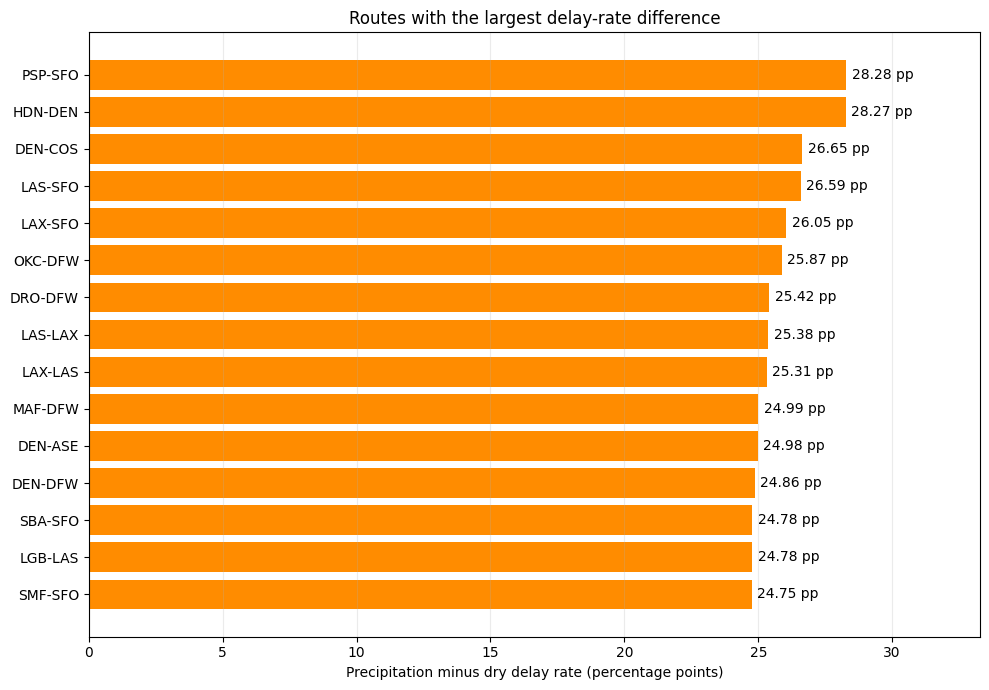

In [ ]:
# The map shows where the routes are; this chart makes the values easier to read.
top_15 = (
    top_routes_pd
    .nlargest(15, "delay_percentage_increase")
    .sort_values("delay_percentage_increase")
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_15["ROUTE"],
    top_15["delay_percentage_increase"],
    color="darkorange"
)

ax.bar_label(bars, fmt="%.2f pp", padding=4)
ax.set_xlabel("Precipitation minus dry delay rate (percentage points)")
ax.set_title("Routes with the largest delay-rate difference")
ax.set_xlim(0, top_15["delay_percentage_increase"].max() + 5)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig("top_15_route_delay_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

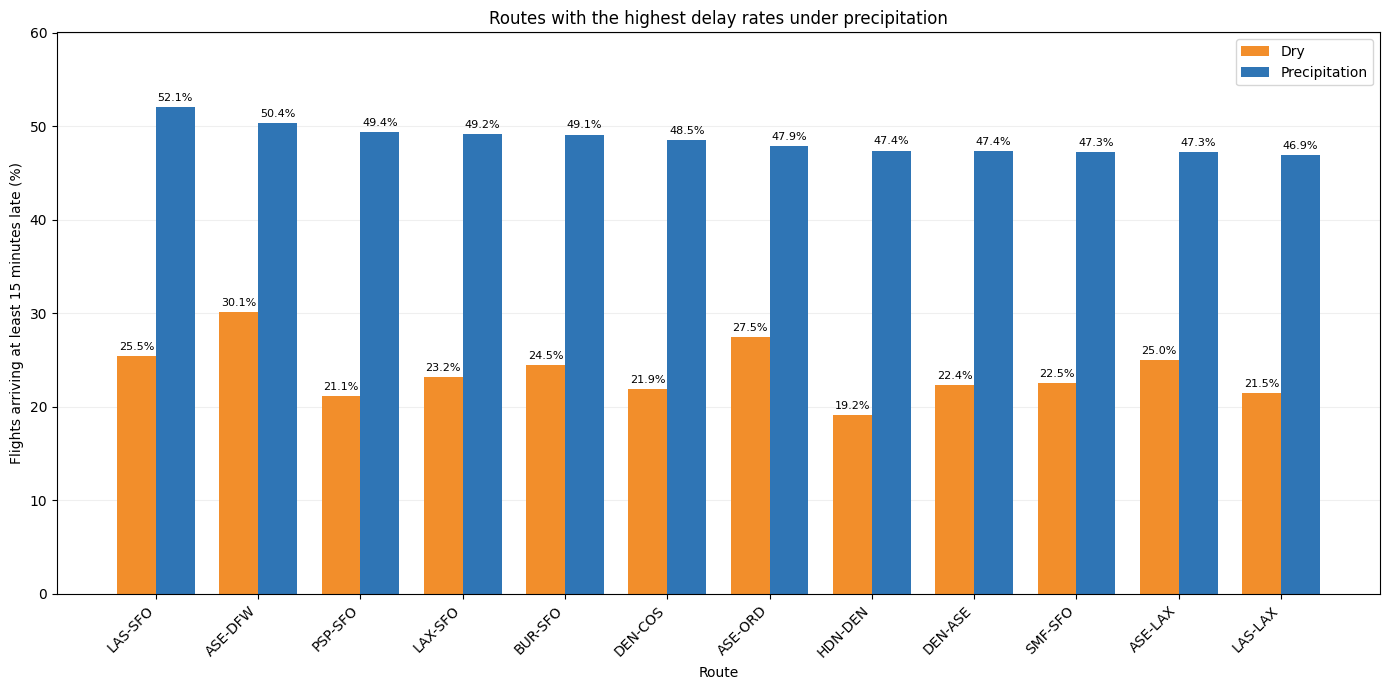

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

route_plot = (
    route_weather
    .orderBy(F.desc("rain_delay_percentage"))
    .limit(12)
    .toPandas()
    .sort_values("rain_delay_percentage", ascending=False)
    .reset_index(drop=True)
)

positions = np.arange(len(route_plot))
column_width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

dry_columns = ax.bar(
    positions - column_width / 2,
    route_plot["dry_delay_percentage"],
    width=column_width,
    color="#F28E2B",
    label="Dry"
)

wet_columns = ax.bar(
    positions + column_width / 2,
    route_plot["rain_delay_percentage"],
    width=column_width,
    color="#2F75B5",
    label="Precipitation"
)

ax.bar_label(dry_columns, fmt="%.1f%%", padding=3, fontsize=8)
ax.bar_label(wet_columns, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(positions)
ax.set_xticklabels(route_plot["ROUTE"], rotation=45, ha="right")
ax.set_xlabel("Route")
ax.set_ylabel("Flights arriving at least 15 minutes late (%)")
ax.set_title("Routes with the highest delay rates under precipitation")

highest_rate = max(
    route_plot["dry_delay_percentage"].max(),
    route_plot["rain_delay_percentage"].max()
)
ax.set_ylim(0, highest_rate + 8)

ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("route_dry_vs_precipitation.png", dpi=300, bbox_inches="tight")
plt.show()

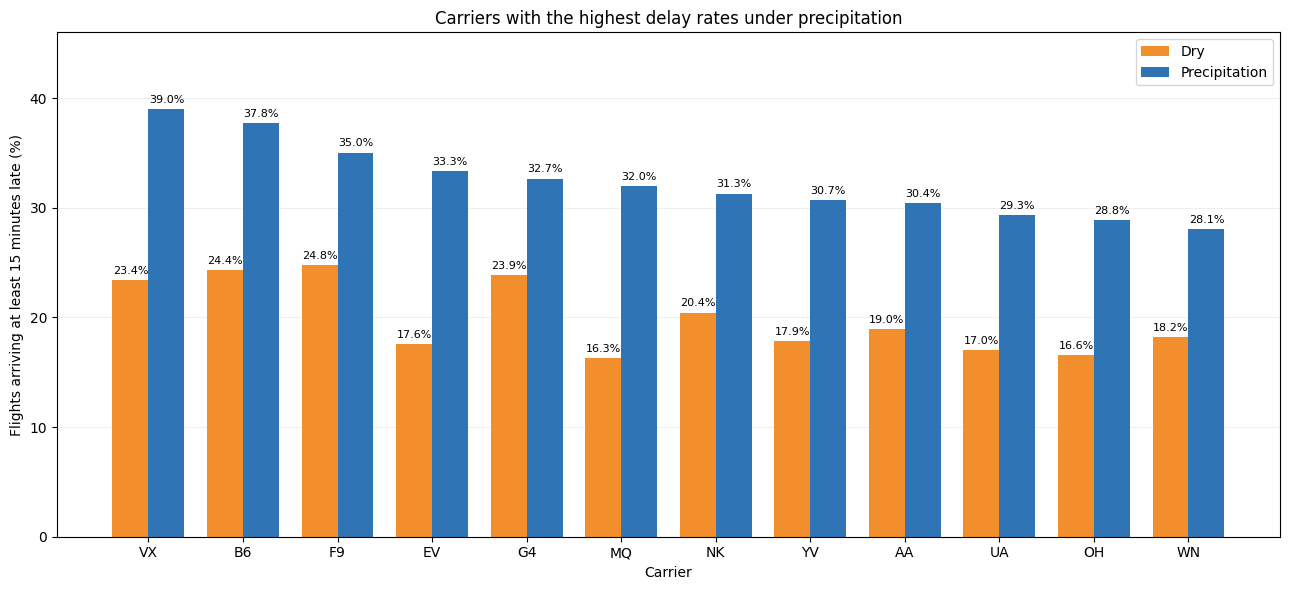

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

carrier_plot = (
    carrier_weather
    .orderBy(F.desc("rain_delay_percentage"))
    .limit(12)
    .toPandas()
    .sort_values("rain_delay_percentage", ascending=False)
    .reset_index(drop=True)
)

positions = np.arange(len(carrier_plot))
column_width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

dry_columns = ax.bar(
    positions - column_width / 2,
    carrier_plot["dry_delay_percentage"],
    width=column_width,
    color="#F28E2B",
    label="Dry"
)

wet_columns = ax.bar(
    positions + column_width / 2,
    carrier_plot["rain_delay_percentage"],
    width=column_width,
    color="#2F75B5",
    label="Precipitation"
)

ax.bar_label(dry_columns, fmt="%.1f%%", padding=3, fontsize=8)
ax.bar_label(wet_columns, fmt="%.1f%%", padding=3, fontsize=8)

ax.set_xticks(positions)
ax.set_xticklabels(carrier_plot["OP_CARRIER"])
ax.set_xlabel("Carrier")
ax.set_ylabel("Flights arriving at least 15 minutes late (%)")
ax.set_title("Carriers with the highest delay rates under precipitation")

highest_rate = max(
    carrier_plot["dry_delay_percentage"].max(),
    carrier_plot["rain_delay_percentage"].max()
)
ax.set_ylim(0, highest_rate + 7)

ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("carrier_dry_vs_precipitation.png", dpi=300, bbox_inches="tight")
plt.show()

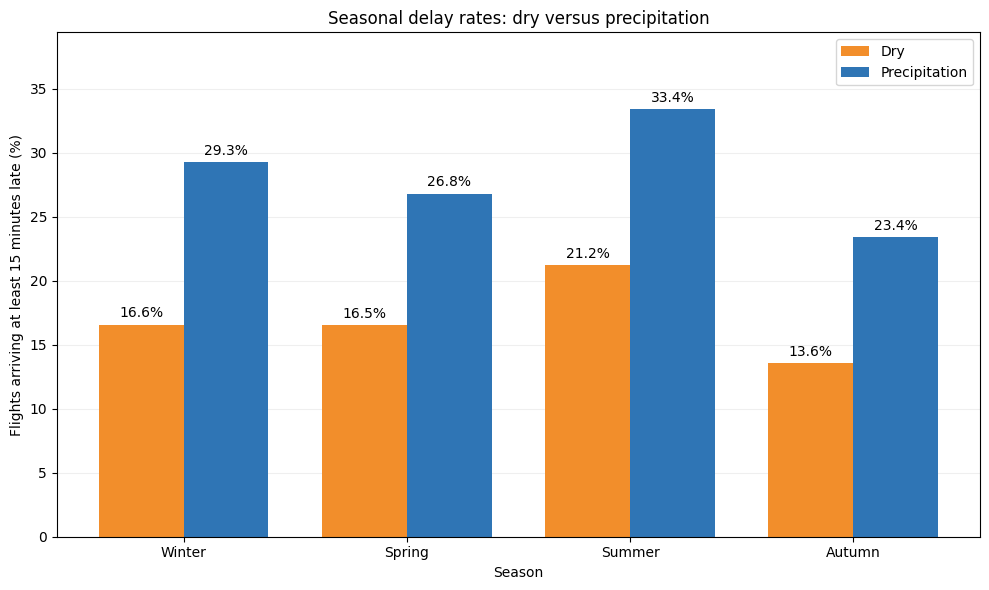

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F

# Assign each flight to a Northern Hemisphere season.
season = (
    F.when(F.col("MONTH").isin(12, 1, 2), "Winter")
     .when(F.col("MONTH").isin(3, 4, 5), "Spring")
     .when(F.col("MONTH").isin(6, 7, 8), "Summer")
     .otherwise("Autumn")
)

# Calculate the percentage of flights arriving at least 15 minutes late.
seasonal_results = (
    df_clean
    .filter(F.col("PRECIPITATION_CATEGORY").isin("Dry", "Precipitation"))
    .withColumn("SEASON", season)
    .groupBy("SEASON", "PRECIPITATION_CATEGORY")
    .agg((F.avg("DELAYED_15") * 100).alias("delay_rate"))
    .toPandas()
)

season_order = ["Winter", "Spring", "Summer", "Autumn"]

seasonal_plot = (
    seasonal_results
    .pivot(index="SEASON", columns="PRECIPITATION_CATEGORY", values="delay_rate")
    .reindex(season_order)
)

positions = np.arange(len(season_order))
column_width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))

dry_columns = ax.bar(
    positions - column_width / 2,
    seasonal_plot["Dry"],
    width=column_width,
    color="#F28E2B",
    label="Dry"
)

wet_columns = ax.bar(
    positions + column_width / 2,
    seasonal_plot["Precipitation"],
    width=column_width,
    color="#2F75B5",
    label="Precipitation"
)

ax.bar_label(dry_columns, fmt="%.1f%%", padding=3)
ax.bar_label(wet_columns, fmt="%.1f%%", padding=3)

ax.set_xticks(positions)
ax.set_xticklabels(season_order)
ax.set_xlabel("Season")
ax.set_ylabel("Flights arriving at least 15 minutes late (%)")
ax.set_title("Seasonal delay rates: dry versus precipitation")
ax.set_ylim(0, seasonal_plot.max().max() + 6)
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("seasonal_delay_rates.png", dpi=300, bbox_inches="tight")
plt.show()

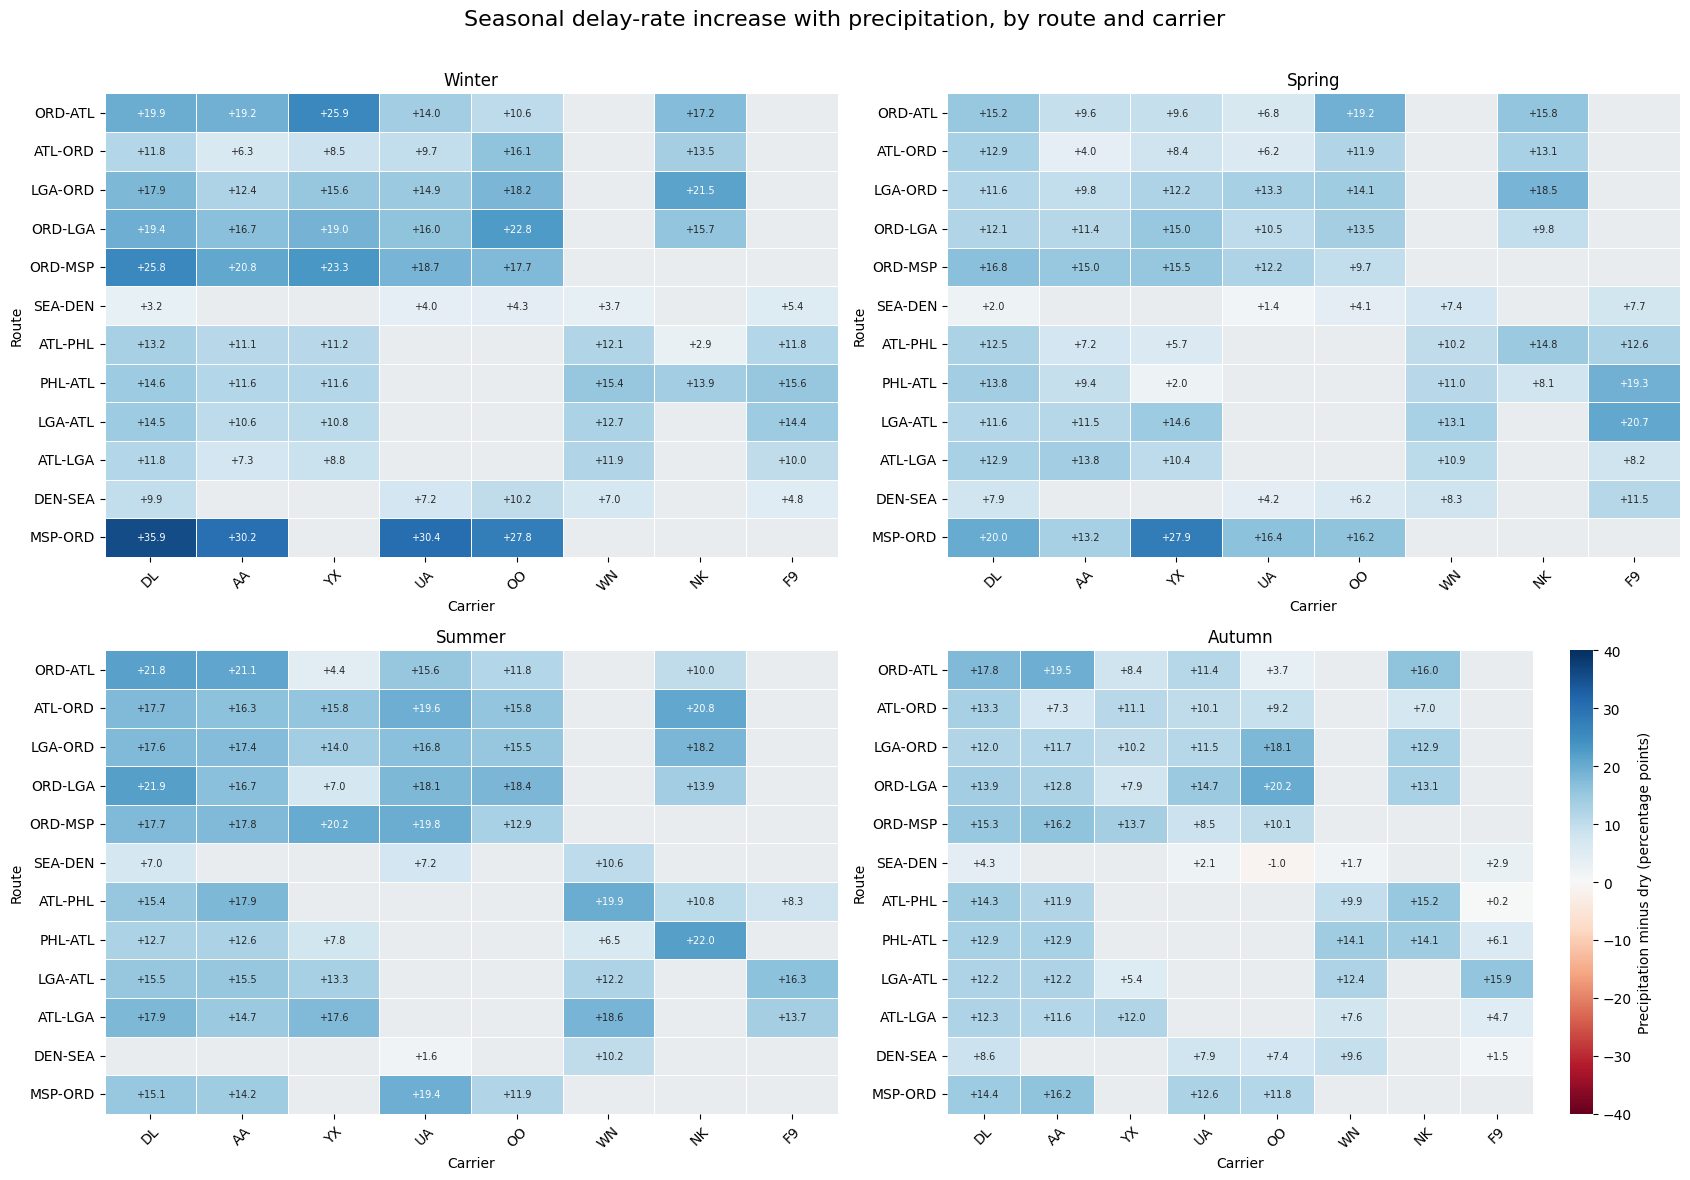

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# These are Northern Hemisphere seasons because the flights are in the US.
season = (
    F.when(F.col("MONTH").isin(12, 1, 2), "Winter")
     .when(F.col("MONTH").isin(3, 4, 5), "Spring")
     .when(F.col("MONTH").isin(6, 7, 8), "Summer")
     .otherwise("Autumn")
)

flights = (
    df_clean
    .filter(F.col("MONTH").isNotNull())
    .filter(F.col("PRECIPITATION_CATEGORY").isin("Dry", "Precipitation"))
    .withColumn("SEASON", season)
)

is_dry = F.col("PRECIPITATION_CATEGORY") == "Dry"
is_wet = F.col("PRECIPITATION_CATEGORY") == "Precipitation"

# Calculate flight counts and delay rates for each combination.
comparisons = (
    flights
    .groupBy("SEASON", "ROUTE", "OP_CARRIER")
    .agg(
        F.count(F.when(is_dry, 1)).alias("dry_flights"),
        F.count(F.when(is_wet, 1)).alias("wet_flights"),
        F.avg(F.when(is_dry, F.col("DELAYED_15"))).alias("dry_rate"),
        F.avg(F.when(is_wet, F.col("DELAYED_15"))).alias("wet_rate")
    )
    # Leave out comparisons based on very few flights.
    .filter((F.col("dry_flights") >= 300) & (F.col("wet_flights") >= 100))
    .withColumn(
        "increase_pp",
        F.round((F.col("wet_rate") - F.col("dry_rate")) * 100, 1)
    )
    .cache()
)

# Choose routes with comparisons across several carriers and seasons.
route_order = [
    row["ROUTE"]
    for row in (
        comparisons
        .groupBy("ROUTE")
        .agg(
            F.count("*").alias("available_squares"),
            F.countDistinct("OP_CARRIER").alias("carrier_count"),
            F.sum(F.col("dry_flights") + F.col("wet_flights")).alias("flights")
        )
        .filter(F.col("carrier_count") >= 2)
        .orderBy(F.desc("available_squares"), F.desc("flights"))
        .limit(12)
        .collect()
    )
]

carrier_order = [
    row["OP_CARRIER"]
    for row in (
        comparisons
        .filter(F.col("ROUTE").isin(route_order))
        .groupBy("OP_CARRIER")
        .agg(
            F.count("*").alias("available_squares"),
            F.sum(F.col("dry_flights") + F.col("wet_flights")).alias("flights")
        )
        .orderBy(F.desc("available_squares"), F.desc("flights"))
        .limit(8)
        .collect()
    )
]

heatmap_data = (
    comparisons
    .filter(
        F.col("ROUTE").isin(route_order)
        & F.col("OP_CARRIER").isin(carrier_order)
    )
    .select("SEASON", "ROUTE", "OP_CARRIER", "increase_pp")
    .toPandas()
)

if heatmap_data.empty:
    raise ValueError("No route–carrier comparisons met the flight-count limits.")

# Use the same colour scale in all four heatmaps.
colour_limit = max(
    5,
    np.ceil(heatmap_data["increase_pp"].abs().max() / 5) * 5
)

fig, axes = plt.subplots(2, 2, figsize=(17, 12))

for ax, season_name in zip(
    axes.flat, ["Winter", "Spring", "Summer", "Autumn"]
):
    season_data = heatmap_data[heatmap_data["SEASON"] == season_name]

    grid = (
        season_data
        .pivot(index="ROUTE", columns="OP_CARRIER", values="increase_pp")
        .reindex(index=route_order, columns=carrier_order)
    )

    ax.set_facecolor("#E9ECEF")  # Grey squares have insufficient data.

    sns.heatmap(
        grid,
        ax=ax,
        mask=grid.isna(),
        cmap="RdBu",
        center=0,
        vmin=-colour_limit,
        vmax=colour_limit,
        annot=True,
        fmt="+.1f",
        annot_kws={"size": 7},
        linewidths=0.5,
        linecolor="white",
        cbar=(season_name == "Autumn"),
        cbar_kws={"label": "Precipitation minus dry (percentage points)"}
    )

    ax.set_title(season_name)
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Route")
    ax.tick_params(axis="x", labelrotation=45)

fig.suptitle(
    "Seasonal delay-rate increase with precipitation, by route and carrier",
    fontsize=16
)
fig.tight_layout(rect=(0, 0, 1, 0.97))

plt.savefig(
    "seasonal_route_carrier_heatmaps.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from collections import Counter

import airportsdata
import matplotlib.pyplot as plt
import matplotlib.colors as colours
import plotly.graph_objects as go
from pyspark.sql import functions as F

# Start with routes that have a large overall wet–dry delay-rate gap.
candidate_routes = [
    row["ROUTE"]
    for row in (
        route_weather
        .orderBy(F.desc("delay_percentage_increase"))
        .limit(60)
        .select("ROUTE")
        .collect()
    )
]

# These are US flights, so use Northern Hemisphere seasons.
season = (
    F.when(F.col("MONTH").isin(12, 1, 2), "Winter")
     .when(F.col("MONTH").isin(3, 4, 5), "Spring")
     .when(F.col("MONTH").isin(6, 7, 8), "Summer")
     .otherwise("Autumn")
)

dry = F.col("PRECIPITATION_CATEGORY") == "Dry"
wet = F.col("PRECIPITATION_CATEGORY") == "Precipitation"

# Calculate dry and precipitation delay rates for each route and season.
seasonal_routes = (
    df_clean
    .filter(F.col("ROUTE").isin(candidate_routes))
    .filter(F.col("MONTH").isNotNull())
    .filter(F.col("PRECIPITATION_CATEGORY").isin("Dry", "Precipitation"))
    .withColumn("SEASON", season)
    .groupBy("SEASON", "ROUTE")
    .agg(
        F.count(F.when(dry, 1)).alias("dry_flights"),
        F.count(F.when(wet, 1)).alias("wet_flights"),
        F.avg(F.when(dry, F.col("DELAYED_15"))).alias("dry_rate"),
        F.avg(F.when(wet, F.col("DELAYED_15"))).alias("wet_rate")
    )
    .filter(
        (F.col("dry_flights") >= 300)
        & (F.col("wet_flights") >= 100)
    )
    .withColumn(
        "gap_pp",
        F.round((F.col("wet_rate") - F.col("dry_rate")) * 100, 2)
    )
    .cache()
)

# Keep routes with enough flights in all four seasons.
routes_with_four_seasons = {
    row["ROUTE"]
    for row in (
        seasonal_routes
        .groupBy("ROUTE")
        .agg(F.countDistinct("SEASON").alias("season_count"))
        .filter(F.col("season_count") == 4)
        .select("ROUTE")
        .collect()
    )
}

airport_directory = airportsdata.load("IATA")

def has_coordinates(route):
    origin, destination = route.split("-", 1)

    for code in (origin, destination):
        airport = airport_directory.get(code)
        if airport is None:
            return False
        if airport.get("lat") is None or airport.get("lon") is None:
            return False

    return True

# Use the same 50 routes in every season.
selected_routes = [
    route
    for route in candidate_routes
    if route in routes_with_four_seasons and has_coordinates(route)
][:50]

if not selected_routes:
    raise ValueError(
        "No routes met the limits in all four seasons. "
        "Try reducing wet_flights from 100 to 50."
    )

map_data = (
    seasonal_routes
    .filter(F.col("ROUTE").isin(selected_routes))
    .toPandas()
)

# Fix the colour scale across all four seasons.
colour_limit = max(1.0, float(map_data["gap_pp"].abs().max()))
normalise = colours.Normalize(vmin=-colour_limit, vmax=colour_limit)
palette = plt.get_cmap("RdBu")  # Red = lower; blue = higher with precipitation.

map_fig = go.Figure()
trace_seasons = []
season_names = ["Winter", "Spring", "Summer", "Autumn"]

for season_name in season_names:
    season_data = map_data[map_data["SEASON"] == season_name]
    season_data = season_data.set_index("ROUTE")

    for route in selected_routes:
        result = season_data.loc[route]
        origin, destination = route.split("-", 1)

        origin_airport = airport_directory[origin]
        destination_airport = airport_directory[destination]

        line_colour = colours.to_hex(
            palette(normalise(float(result["gap_pp"])))
        )

        hover_text = (
            f"<b>{origin} → {destination}</b><br>"
            f"{season_name}<br>"
            f"Dry: {result['dry_rate'] * 100:.1f}% "
            f"({int(result['dry_flights']):,} flights)<br>"
            f"Precipitation: {result['wet_rate'] * 100:.1f}% "
            f"({int(result['wet_flights']):,} flights)<br>"
            f"Difference: {result['gap_pp']:+.1f} percentage points"
        )

        map_fig.add_trace(go.Scattergeo(
            lon=[origin_airport["lon"], destination_airport["lon"]],
            lat=[origin_airport["lat"], destination_airport["lat"]],
            mode="lines",
            line=dict(width=2.6, color=line_colour),
            opacity=0.85,
            text=[hover_text, hover_text],
            hoverinfo="text",
            visible=(season_name == "Winter"),
            showlegend=False
        ))
        trace_seasons.append(season_name)

# Add one colour bar that remains visible as the season changes.
first_origin = selected_routes[0].split("-", 1)[0]
first_airport = airport_directory[first_origin]

map_fig.add_trace(go.Scattergeo(
    lon=[first_airport["lon"], first_airport["lon"]],
    lat=[first_airport["lat"], first_airport["lat"]],
    mode="markers",
    marker=dict(
        size=1,
        color=[-colour_limit, colour_limit],
        colorscale="RdBu",
        cmin=-colour_limit,
        cmax=colour_limit,
        showscale=True,
        colorbar=dict(
            title="Wet − dry<br>(percentage points)",
            thickness=16
        )
    ),
    hoverinfo="skip",
    showlegend=False
))
trace_seasons.append("shared")

# Show airport names for the most frequently used endpoints.
airport_codes = sorted({
    code
    for route in selected_routes
    for code in route.split("-", 1)
})

endpoint_counts = Counter(
    code
    for route in selected_routes
    for code in route.split("-", 1)
)
labelled_airports = {
    code for code, count in endpoint_counts.most_common(6)
}

map_fig.add_trace(go.Scattergeo(
    lon=[airport_directory[code]["lon"] for code in airport_codes],
    lat=[airport_directory[code]["lat"] for code in airport_codes],
    mode="markers+text",
    marker=dict(size=6, color="#123B5D"),
    text=[
        airport_directory[code].get("name", code)
        if code in labelled_airports else ""
        for code in airport_codes
    ],
    textposition="top center",
    textfont=dict(size=8, color="#123B5D"),
    hovertext=[
        f"{airport_directory[code].get('name', code)} ({code})"
        for code in airport_codes
    ],
    hoverinfo="text",
    showlegend=False
))
trace_seasons.append("shared")

def map_title(season_name):
    return (
        f"Precipitation-associated delay-rate gap — {season_name}"
        "<br><sup>Arrival delay ≥15 minutes; precipitation at departure "
        "or arrival airport; same routes and colour scale in every season</sup>"
    )

# The dropdown shows one season's route lines at a time.
buttons = [
    dict(
        label=season_name,
        method="update",
        args=[
            {
                "visible": [
                    trace_season in (season_name, "shared")
                    for trace_season in trace_seasons
                ]
            },
            {"title": map_title(season_name)}
        ]
    )
    for season_name in season_names
]

map_fig.update_geos(
    scope="usa",
    projection_type="albers usa",
    showland=True,
    landcolor="#F3F6F9",
    showsubunits=True,
    subunitcolor="white",
    showlakes=True,
    lakecolor="white"
)

map_fig.update_layout(
    title=map_title("Winter"),
    height=720,
    margin=dict(l=20, r=110, t=145, b=20),
    paper_bgcolor="white",
    font=dict(family="Arial", color="#123B5D"),
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            active=0,
            buttons=buttons,
            x=0.02,
            y=1.05,
            xanchor="left",
            yanchor="bottom",
            showactive=True
        )
    ]
)

map_fig.show()
map_fig.write_html("seasonal_route_delay_map.html", include_plotlyjs=True)

In [ ]:
import inspect
print(inspect.getsource(delay_by_carrier_rdd))


def delay_by_carrier_rdd(df):
    """
    Explicit low-level RDD MapReduce demonstration.

    Same result as carrier_delay_summary()'s average delay column,
    but implemented via raw map -> reduceByKey rather than the
    DataFrame API, to show the underlying MapReduce mechanics that
    groupBy().agg() abstracts away.
    """
    # Map: emit (carrier, (delay, 1)) pairs — row-level, fully parallel
    pair_rdd = df.select("OP_CARRIER", "ARR_DELAY").rdd.map(
        lambda row: (row["OP_CARRIER"], (row["ARR_DELAY"], 1))
    )

    # Shuffle + Reduce: combine values sharing a key. This is where
    # Spark redistributes data across partitions by key.
    reduced = pair_rdd.reduceByKey(
        lambda a, b: (a[0] + b[0], a[1] + b[1])
    )

    # Final map: compute the average from (sum, count)
    avg_delay_by_carrier = reduced.map(
        lambda kv: (kv[0], round(kv[1][0] / kv[1][1], 2))
    )

    return avg_delay_by_carrier

